# Agent Orchestration: Sequential Multi-Agent Handoffs

Now that we have a single agent running as a state machine, let's add a teammate! In this notebook, we explore the **Sequential Handoff** pattern.

## 1. What is a Sequential Handoff?
Think of this as a **Relay Race**. 
- **Agent A** (e.g., Writer) completes a task.
- **Agent A** passes the result to **Agent B** (e.g., Reviewer).
- **Agent B** performs its specialized task on that result.

This is much more reliable than asking one giant model to do everything at once.

---

## 2. Environment Setup
We use Gemini 2.5 Flash for both agents, but we will give them different "System Instructions."

In [12]:
import os
from typing import Annotated, TypedDict, List
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

print("Gemini Multi-Agent Environment Ready!")

Gemini Multi-Agent Environment Ready!


## 3. Defining the Shared State
Both agents will read from and write to the same message list.

In [13]:
class TeamState(TypedDict):
    # messages are appended automatically
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]

## 4. Defining the Agents (Nodes)
We define two functions: one for the **Generator** and one for the **Reviewer**.

In [14]:
def writer_agent(state: TeamState):
    system_msg = SystemMessage(content="You are a creative writer. Write a 4-line poem about the user's topic.")
    # We combine the system message with the user's query
    messages = [system_msg] + state["messages"]
    response = llm.invoke(messages)
    return {"messages": [AIMessage(content=response.content, name="Writer")]}

def reviewer_agent(state: TeamState):
    system_msg = SystemMessage(content="""You are a strict editor. Review the poem provided. 
                               Identify one strength and one core area for improvement.""")
    # The reviewer looks at the entire history, including the writer's poem
    messages = [system_msg] + state["messages"]
    response = llm.invoke(messages)
    return {"messages": [AIMessage(content=response.content, name="Reviewer")]}

## 5. Building & Visualizing the Sequential Graph
The flow is simple: START -> Writer -> Reviewer -> END.

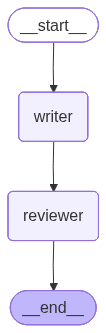

In [15]:
workflow = StateGraph(TeamState)

workflow.add_node("writer", writer_agent)
workflow.add_node("reviewer", reviewer_agent)

workflow.add_edge(START, "writer")
workflow.add_edge("writer", "reviewer")
workflow.add_edge("reviewer", END)

app = workflow.compile()

# Visualize the graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed. (Ensure pygraphviz or mermaid is available)")

## 6. Running the Handoff
Let's see how the context flows from the user to the writer, and then the writer's work flows to the reviewer.

In [16]:
inputs = {"messages": [HumanMessage(content="Write a poem about space exploration.")]}

for chunk in app.stream(inputs, stream_mode="values"):
    message = chunk["messages"][-1]
    if hasattr(message, "name") and message.name:
        print(f"\n--- {message.name} Agent Output ---")
        print(message.content)


--- Writer Agent Output ---
Through cosmic dust, our vessels soar,
To touch the stars, and seek new shore.
Brave spirits journey, far and wide,
Where unknown wonders softly ride.

--- Reviewer Agent Output ---


From Earth's embrace, a distant gleam,
We chase the universe's dream.
Past fiery suns and icy rings,
The silent void, new knowledge brings.

With probes that whisper, 'we are here,'
Across the light-years, banishing fear.
On Martian plains, a rover crawls,
Unveiling secrets, breaking walls.

The moon, a stepping stone, so grand,
A human footprint on its sand.
And deeper still, where giants sleep,
We send our hopes, the promises we keep.

For in that vast and silent night,
Reflects our quest, for truth and light.
To understand, to reach, to know,
The seeds of wonder, we will sow.


## 7. Advanced: The "Critic" Loop (Evaluator-Optimizer)
What if the reviewer isn't happy? In a sequential handoff, the flow ends. In a **State Machine**, we can add a decision node to send the work *back* to the writer.

Here is how we implement a loop that allows up to 2 revisions.

Critic Loop Compiled!


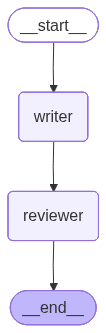


[None] (Revision: 0):
Write a poem about debugging code....

[Writer] (Revision: 1):
A cryptic error, a silent plea,
Through tangled lines, you hunt for me.
One missing semicolon, a tin...

[Critic] (Revision: 1):
CRITIQUE: This is a good start, but it's a bit simplistic. Try to expand on the emotional journey of...

[Writer] (Revision: 2):


REVISION:
A cryptic error, a silent plea,
Through tangled lines, you hunt for me.
One missing semi...

[Critic] (Revision: 2):
CRITIQUE: The revised poem is an improvement, especially with "compiler screams, a crimson blight" a...


In [17]:
from pydantic import BaseModel, Field

class Feedback(BaseModel):
    """Structured feedback from the editor."""
    is_approved: bool = Field(description="True if the poem is perfect, False if it needs changes.")
    critique: str = Field(description="Specific instructions for the writer to improve the poem.")

# 1. Enhanced State with a revision counter
class LoopState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]
    revisions: int
    is_approved: bool

# 2. Structured Critic
critic_llm = llm.with_structured_output(Feedback)

def reviewer_with_feedback(state: LoopState):
    system_msg = SystemMessage(content="You are a strict editor. Review the poem. If it's not great, provide a critique.")
    # We only care about the latest poem for the structured critique
    response = critic_llm.invoke([system_msg] + state["messages"])
    
    # We add the critique as a message so the writer can see it
    feedback_msg = AIMessage(content=f"CRITIQUE: {response.critique}", name="Critic")
    return {"messages": [feedback_msg], "is_approved": response.is_approved}

# 3. Routing Logic
def should_revise(state: LoopState):
    # If approved OR we've reached 2 revisions, stop.
    if state.get("is_approved") or state.get("revisions", 0) >= 2:
        return END
    return "writer"

def writer_with_counter(state: LoopState):
    # Increment revisions
    new_revisions = state.get("revisions", 0) + 1
    res = writer_agent(state) # reuse original writer logic
    res["revisions"] = new_revisions
    return res

# 4. Build & Visualize the Loop Graph
builder = StateGraph(LoopState)
builder.add_node("writer", writer_with_counter)
builder.add_node("reviewer", reviewer_with_feedback)

builder.add_edge(START, "writer")
builder.add_edge("writer", "reviewer")
builder.add_conditional_edges("reviewer", should_revise)

loop_app = builder.compile()
print("Critic Loop Compiled!")

# Visualize
try:
    display(Image(loop_app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# Test the loop
test_inputs = {"messages": [HumanMessage(content="Write a poem about debugging code.")], "revisions": 0}
for chunk in loop_app.stream(test_inputs, stream_mode="values"):
    msg = chunk["messages"][-1]
    name = getattr(msg, "name", "User")
    print(f"\n[{name}] (Revision: {chunk.get('revisions', 0)}):\n{msg.content[:100]}...")

## 8. Summary & Pro-Tips
1. **State is Shared**: Notice that the Reviewer didn't need to be told the "Topic." It read the topic and the poem directly from the shared `AgentState`.
2. **Agent Isolation**: By giving each agent a different `SystemMessage`, we force them to stick to their persona. This reduces "Executive Overload" on the LLM.
3. **Handoffs at Scale**: You can chain 10 agents this way (e.g., Code -> Review -> Test -> Deploy).

---